<a href="https://colab.research.google.com/github/yasaer123/My-resume/blob/main/OCD_Patient_Dataset__Demographics_%26_Clinical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('OCD Patient Dataset_ Demographics & Clinical Data.csv')

In [9]:
print(df.head())

   Patient ID  Age  Gender Ethnicity Marital Status Education Level  \
0        1018   32  Female   African         Single    Some College   
1        2406   69    Male   African       Divorced    Some College   
2        1188   57    Male  Hispanic       Divorced  College Degree   
3        6200   27  Female  Hispanic        Married  College Degree   
4        5824   56  Female  Hispanic        Married     High School   

  OCD Diagnosis Date  Duration of Symptoms (months) Previous Diagnoses  \
0         2016-07-15                            203                MDD   
1         2017-04-28                            180                NaN   
2         2018-02-02                            173                MDD   
3         2014-08-25                            126               PTSD   
4         2022-02-20                            168               PTSD   

  Family History of OCD Obsession Type Compulsion Type  \
0                    No   Harm-related        Checking   
1           

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1252 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

In [10]:
print(df.isnull().sum())

Patient ID                         0
Age                                0
Gender                             0
Ethnicity                          0
Marital Status                     0
Education Level                    0
OCD Diagnosis Date                 0
Duration of Symptoms (months)      0
Previous Diagnoses               248
Family History of OCD              0
Obsession Type                     0
Compulsion Type                    0
Y-BOCS Score (Obsessions)          0
Y-BOCS Score (Compulsions)         0
Depression Diagnosis               0
Anxiety Diagnosis                  0
Medications                      386
dtype: int64


In [11]:
print(df.describe())

        Patient ID          Age  Duration of Symptoms (months)  \
count  1500.000000  1500.000000                    1500.000000   
mean   5541.254000    46.781333                     121.745333   
std    2562.389469    16.830321                      67.404610   
min    1017.000000    18.000000                       6.000000   
25%    3338.000000    32.000000                      64.000000   
50%    5539.500000    47.000000                     121.000000   
75%    7745.500000    61.000000                     178.000000   
max    9995.000000    75.000000                     240.000000   

       Y-BOCS Score (Obsessions)  Y-BOCS Score (Compulsions)  
count                1500.000000                  1500.00000  
mean                   20.048000                    19.62600  
std                    11.823884                    11.78287  
min                     0.000000                     0.00000  
25%                    10.000000                     9.00000  
50%                    20.0

In [12]:
print(df.describe(include=['O']))

       Gender  Ethnicity Marital Status Education Level OCD Diagnosis Date  \
count    1500       1500           1500            1500               1500   
unique      2          4              3               4               1218   
top      Male  Caucasian         Single    Some College         2017-06-21   
freq      753        398            511             394                  4   

       Previous Diagnoses Family History of OCD Obsession Type  \
count                1252                  1500           1500   
unique                  4                     2              5   
top                   MDD                   Yes   Harm-related   
freq                  345                   760            333   

       Compulsion Type Depression Diagnosis Anxiety Diagnosis     Medications  
count             1500                 1500              1500            1114  
unique               5                    2                 2               3  
top            Washing                

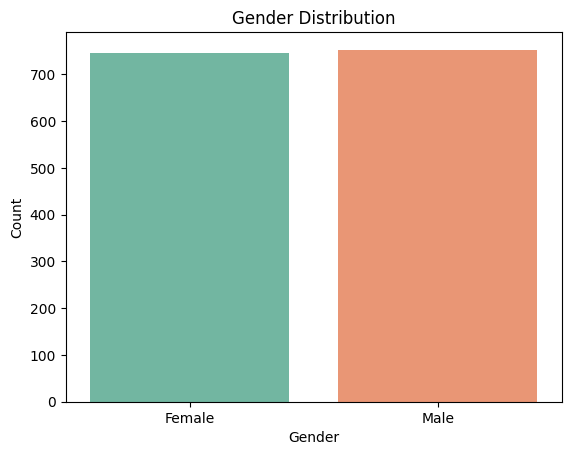

In [32]:
# Gender

palette_colors = sns.color_palette("Set2")

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

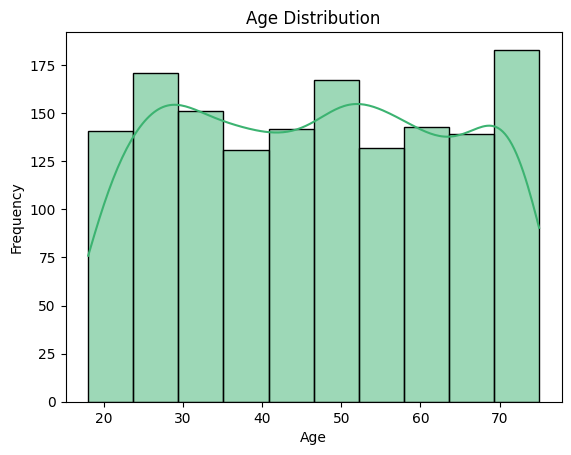

In [33]:
# Age
sns.histplot(df["Age"], bins=10, kde=True, color="mediumseagreen", edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

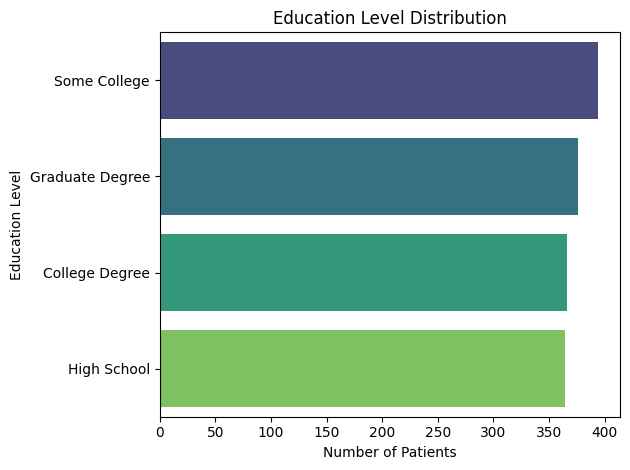

In [34]:
# Education Level
sns.countplot(
    y="Education Level",
    data=df,
    order=df["Education Level"].value_counts().index,
    palette="viridis"  # You can also try: "pastel", "Set2", "Blues", etc.
)

plt.title("Education Level Distribution")
plt.xlabel("Number of Patients")
plt.ylabel("Education Level")

plt.tight_layout()
plt.show()

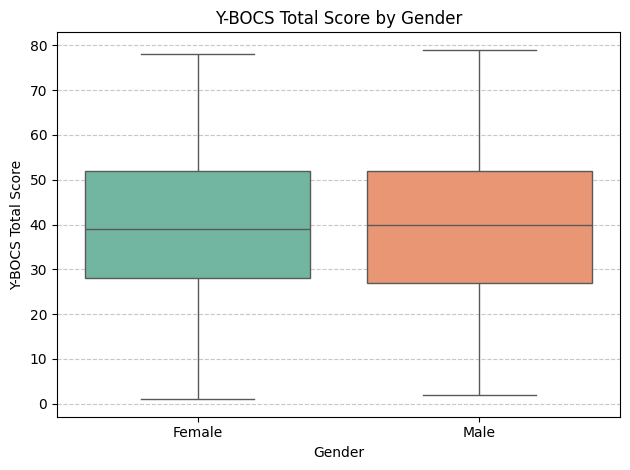

In [35]:
# Y-BOCS Total
df["YBOCS Total"] = df["Y-BOCS Score (Obsessions)"] + df["Y-BOCS Score (Compulsions)"]

# Gender vs Severity
sns.boxplot(
    x="Gender",
    y="YBOCS Total",
    data=df,
    palette="Set2"  # Try "Pastel1", "Set1", etc.
)

plt.title("Y-BOCS Total Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Y-BOCS Total Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

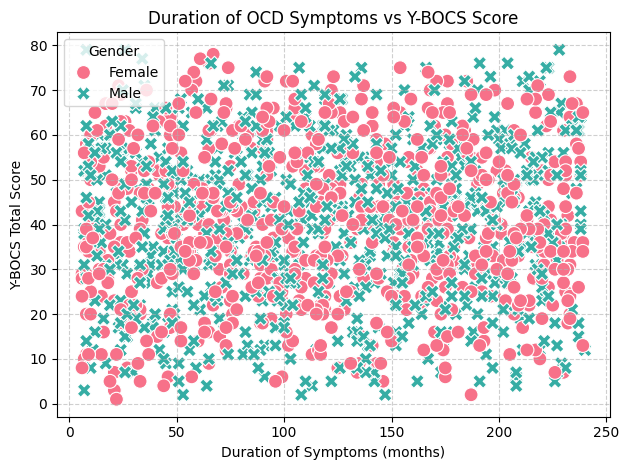

In [37]:
#scatterplot
sns.scatterplot(
    x="Duration of Symptoms (months)",
    y="YBOCS Total",
    hue="Gender",
    data=df,
    palette="husl",
    style="Gender",
    s=100  # Size of points
)

plt.title("Duration of OCD Symptoms vs Y-BOCS Score")
plt.xlabel("Duration of Symptoms (months)")
plt.ylabel("Y-BOCS Total Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

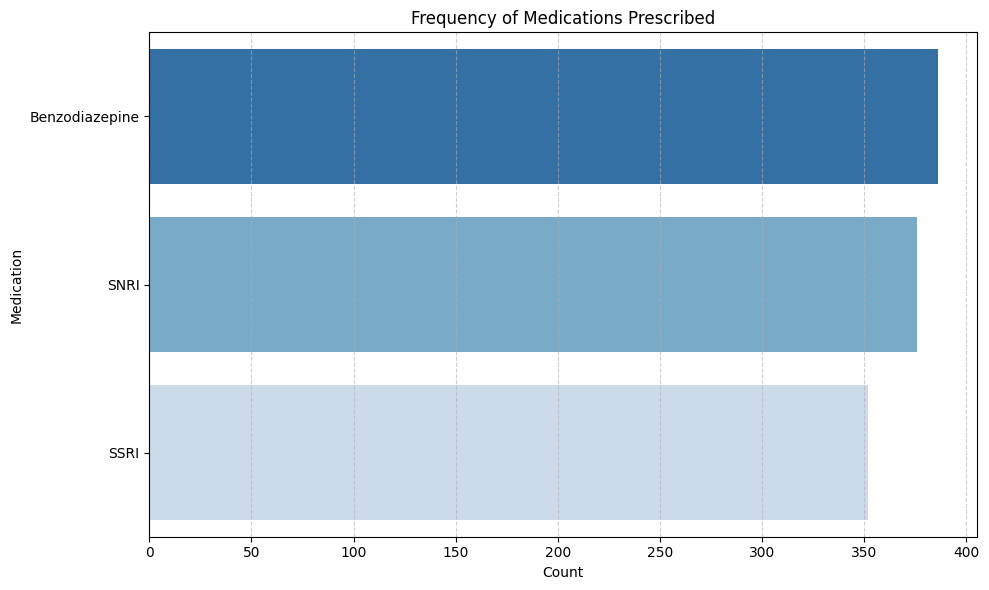

In [38]:
# Medication count
plt.figure(figsize=(10, 6))
sns.countplot(
    y="Medications",
    data=df,
    order=df["Medications"].value_counts().index,
    palette="Blues_r"
)
plt.title("Frequency of Medications Prescribed")
plt.xlabel("Count")
plt.ylabel("Medication")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

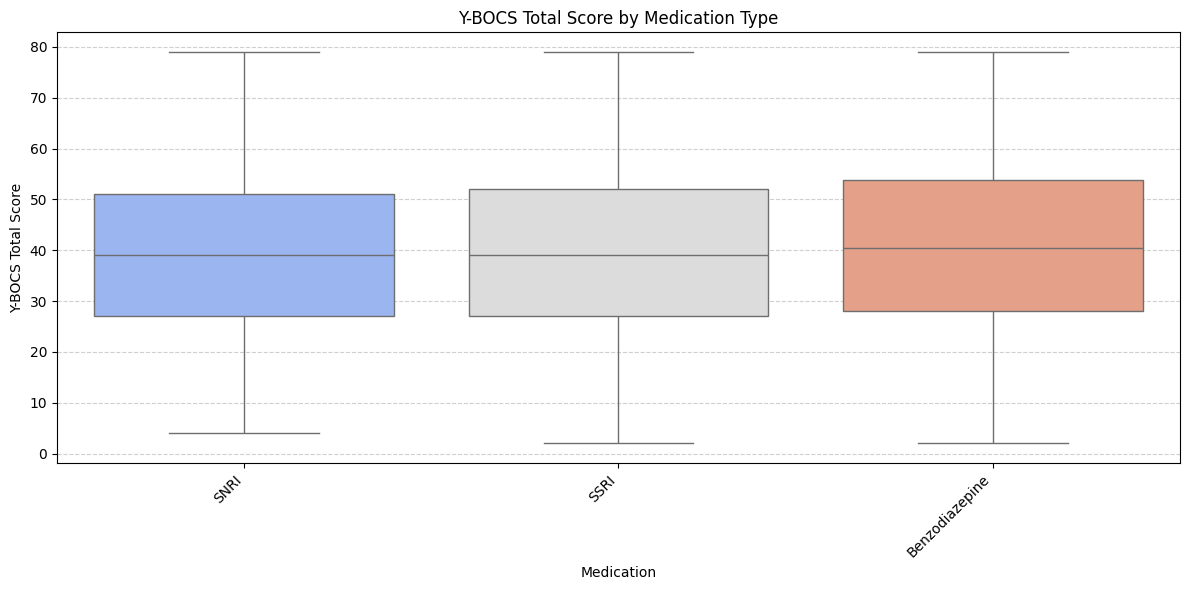

In [39]:
# Medication vs Severity
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Medications",
    y="YBOCS Total",
    data=df,
    palette="coolwarm"
)
plt.title("Y-BOCS Total Score by Medication Type")
plt.xlabel("Medication")
plt.ylabel("Y-BOCS Total Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

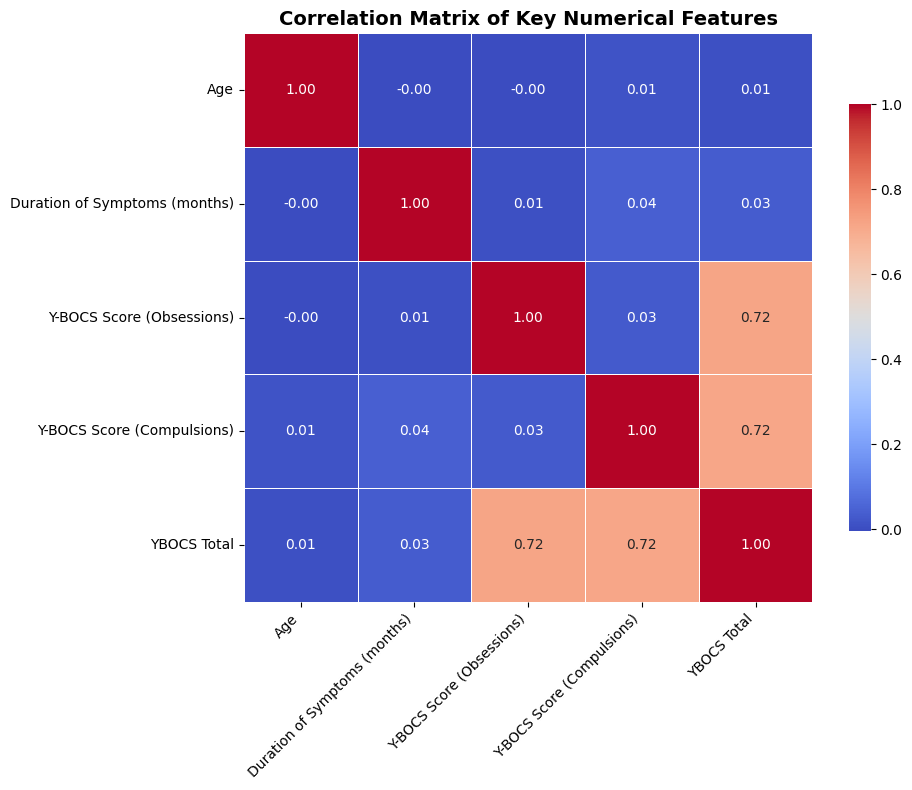

Correlation Matrix:

                                Age  Duration of Symptoms (months)  \
Age                            1.00                          -0.00   
Duration of Symptoms (months) -0.00                           1.00   
Y-BOCS Score (Obsessions)     -0.00                           0.01   
Y-BOCS Score (Compulsions)     0.01                           0.04   
YBOCS Total                    0.01                           0.03   

                               Y-BOCS Score (Obsessions)  \
Age                                                -0.00   
Duration of Symptoms (months)                       0.01   
Y-BOCS Score (Obsessions)                           1.00   
Y-BOCS Score (Compulsions)                          0.03   
YBOCS Total                                         0.72   

                               Y-BOCS Score (Compulsions)  YBOCS Total  
Age                                                  0.01         0.01  
Duration of Symptoms (months)                      

In [40]:
#Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75}
)
plt.title("Correlation Matrix of Key Numerical Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the correlation matrix for textual reference
print("Correlation Matrix:\n")
print(corr_matrix.round(2))